# Protocol Performance Analysis

This notebook analyzes the network transmission metrics gathered by the test orchestrator. Our RDT protocol was evaluated under various emulated network conditions using Linux `tc netem`. 

First, we'll load the dependencies and read the aggregated `experiment_results.csv` generated by the test suite.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Load the metrics data
csv_path = "metrics/experiment_results.csv"
df = pd.read_csv(csv_path)

# Clean up Delay and Loss strings to numeric floats for plotting
df["Delay_ms"] = df["Delay"].str.replace("ms", "").astype(float)
df["Loss_pct"] = df["Loss"].str.replace("%", "").astype(float)

display(df)

,Name,Delay,Jitter,Loss,SegSize,Success,TransferTime (s),Throughput (KB/s),Retransmissions,Timeouts (Client),Anomalies (Dup Data/ACKs),Delay_ms,Loss_pct
0,Ideal Network,0ms,0ms,0%,512,True,0.003,2221.42,0,0,0,0.0,0.0
1,Low Delay,50ms,10ms,0%,512,True,0.772,9.56,0,0,0,50.0,0.0
2,Medium Delay,200ms,40ms,0%,512,True,3.094,2.38,0,0,0,200.0,0.0
3,High Delay,500ms,100ms,0%,512,True,7.738,0.95,0,0,0,500.0,0.0
4,Extreme Delay,1500ms,300ms,0%,512,True,25.807,0.29,9,0,16,1500.0,0.0
5,Low Loss,0ms,0ms,2%,512,True,0.004,1873.12,0,0,0,0.0,2.0
6,Medium Loss,0ms,0ms,10%,512,True,0.004,2092.05,0,0,0,0.0,10.0
7,High Loss,0ms,0ms,25%,512,True,6.009,1.23,6,0,0,0.0,25.0
8,Extreme Loss,0ms,0ms,50%,512,True,12.016,0.61,10,2,2,0.0,50.0
9,Mixed Degraded,100ms,20ms,5%,512,True,2.532,2.91,1,0,0,100.0,5.0


## Impact of Network Delay on Throughput

Because our custom RDT relies on a simple Stop-and-Wait architecture, the client must wait for an ACK after every single segment. As round-trip time (RTT) increases, the time spent sitting idle increases proportionally, sharply capping our maximum throughput.

*Note: The y-axis is plotted on a logarithmic scale because the throughput drops drastically the moment any baseline latency is introduced.*

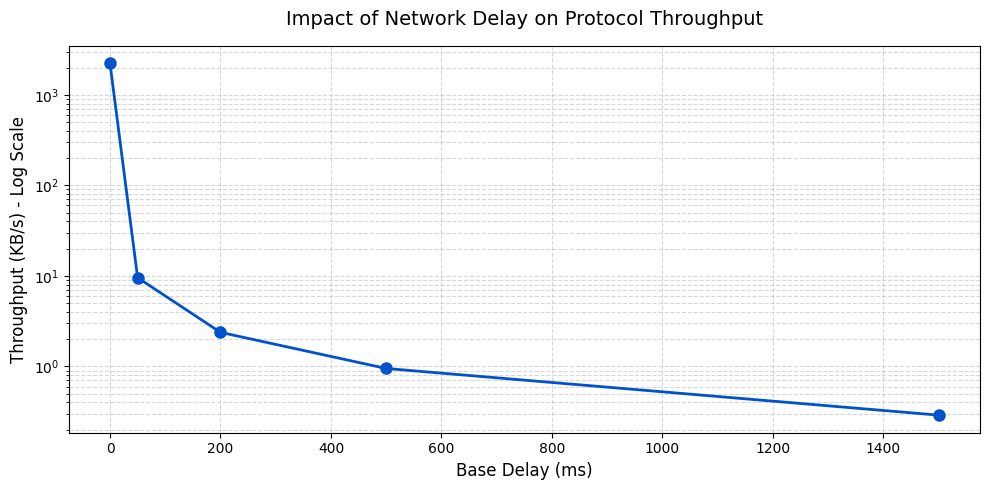

In [19]:
# Filter for runs with 0% loss to isolate delay effects
delay_df = df[df["Loss_pct"] == 0.0].sort_values(by="Delay_ms")

plt.figure(figsize=(10, 5))
plt.plot(
    delay_df["Delay_ms"],
    delay_df["Throughput (KB/s)"],
    marker="o",
    markersize=8,
    linestyle="-",
    linewidth=2,
    color="#0052cc",
)

plt.title("Impact of Network Delay on Protocol Throughput", fontsize=14, pad=15)
plt.xlabel("Base Delay (ms)", fontsize=12)
plt.ylabel("Throughput (KB/s) - Log Scale", fontsize=12)

# Use a log scale to better visualize the massive drop from 0ms to 50ms
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Impact of Packet Loss on Throughput

While delay causes a steady, proportional decrease in speed, packet loss introduces severe, erratic latency spikes. 

In a Stop-and-Wait protocol, a dropped packet means the sender halts completely until the timeout duration expires (e.g., 1 or 2 full seconds). If the packet loss is low enough (e.g., 2%) on a small file, we might get lucky and experience zero drops, keeping throughput identical to an ideal network. However, once the drop rate increases enough to guarantee a dropped packet (e.g., 15%), the resulting timeout stall absolutely decodes the transfer speed, creating a large sudden drop in throughput.

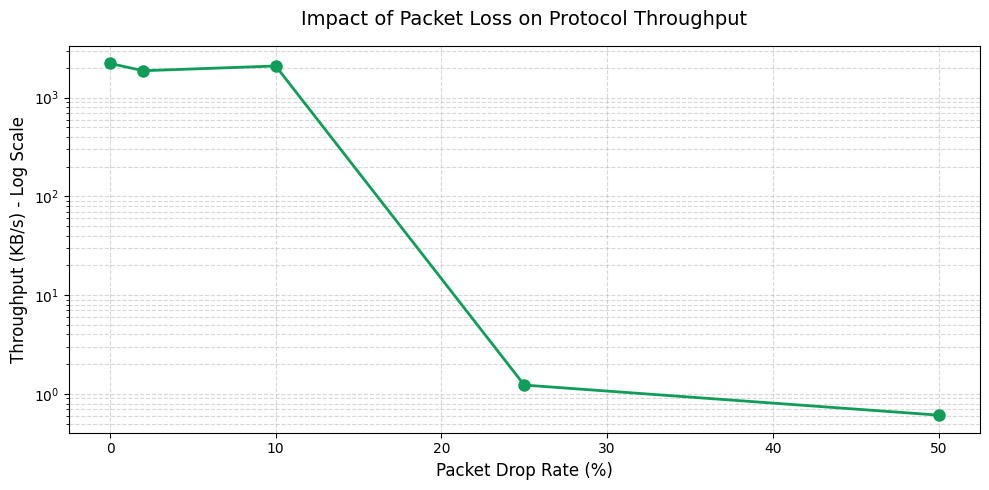

In [20]:
# Filter for runs with 0ms delay to isolate loss effects
loss_df = df[df["Delay_ms"] == 0.0].sort_values(by="Loss_pct")

plt.figure(figsize=(10, 5))

plt.plot(
    loss_df["Loss_pct"],
    loss_df["Throughput (KB/s)"],
    marker="o",
    markersize=8,
    linestyle="-",
    linewidth=2,
    color="#0f9d58",
)

plt.title("Impact of Packet Loss on Protocol Throughput", fontsize=14, pad=15)
plt.xlabel("Packet Drop Rate (%)", fontsize=12)
plt.ylabel("Throughput (KB/s) - Log Scale", fontsize=12)

# Log scale used again to show the sudden drop caused by timeout stalls
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Impact of Packet Loss on Retransmissions

Packet loss directly triggers the protocol's timeout mechanisms. Whenever the server sends a DATA packet that gets dropped, or the client's ACK gets dropped, the socket timeout period elapses and forces a retransmission. 

The plot below shows how artificial packet loss rates correspond to the volume of retransmissions and anomalies (duplicate packets).

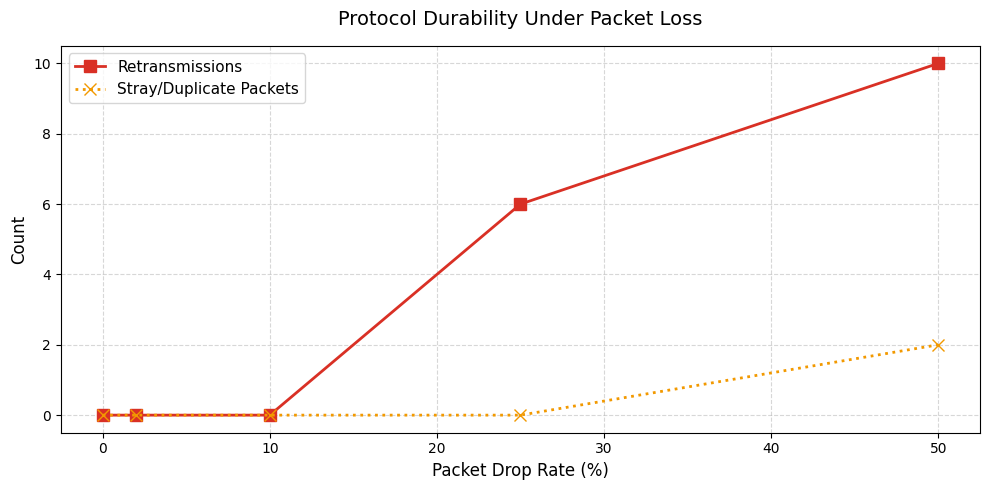

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    loss_df["Loss_pct"],
    loss_df["Retransmissions"],
    marker="s",
    markersize=8,
    linestyle="-",
    linewidth=2,
    color="#d93025",
    label="Retransmissions",
)
ax.plot(
    loss_df["Loss_pct"],
    loss_df["Anomalies (Dup Data/ACKs)"],
    marker="x",
    markersize=8,
    linestyle=":",
    linewidth=2,
    color="#f29900",
    label="Stray/Duplicate Packets",
)

plt.title("Protocol Durability Under Packet Loss", fontsize=14, pad=15)
plt.xlabel("Packet Drop Rate (%)", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Force the y-axis to only show integer values (you can't have 1.5 retransmissions)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()